In [1]:
%pip install qiskit # needed in colab
%pip install pylatexenc
import pylatexenc
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Statevector, Operator

import matplotlib.pyplot as plt

import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=0e7faa0ae90dc02f7ae261cce8c32ccf7e71220301cb2be4fe26d5b7eec92bcb
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


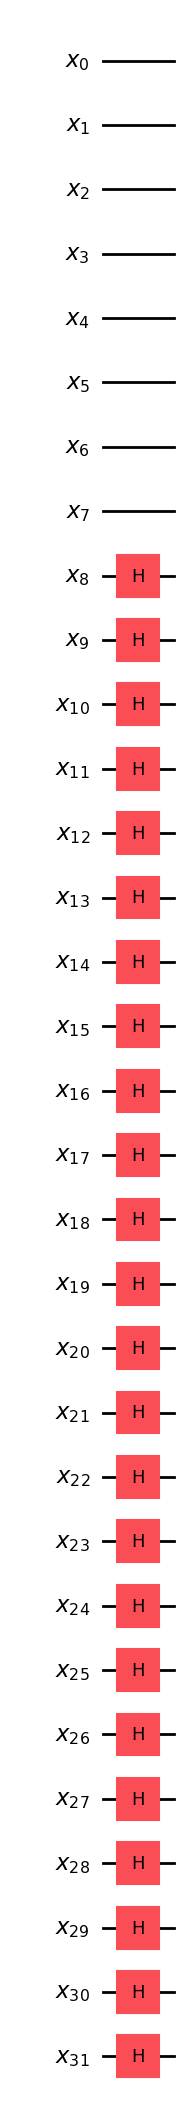

In [10]:
quantum_register = QuantumRegister(size=32, name="x")

# Board has 16 boxes. each box is a number from 1 to 4.
# A 2-qubit has a basis of 4 elements. So need 32 qubits since each box needs
# 2 qubits. enumerate going across each row, left to right.

state_preparation_circuit = QuantumCircuit(quantum_register, name="State preparation")

# Put four ones on the board - do 1 (00), 2 (01), 3 (10), 4 (11) across top row

state_preparation_circuit.x(quantum_register[3])

state_preparation_circuit.x(quantum_register[4])

state_preparation_circuit.x(quantum_register[6])
state_preparation_circuit.x(quantum_register[7])

# make remaining states equivalently likely

state_preparation_circuit.h(quantum_register[8:32])

state_preparation_circuit.draw(output="mpl")

In [4]:
Prep = state_preparation_circuit.to_gate()

In [11]:
#instead of adder like in the second notebook, we need to check when two cells are equal?
# given a block, check with 3 others in row, 3 others in column, and 1 other in box = 7
# have 16*7 = 112 boxes, and each pair then counted twice so just need 56

ancilla_register = AncillaRegister(size=56, name="y")

marker_circuit = QuantumCircuit(quantum_register, ancilla_register, name="marker")

### I'm not sure how to define A so that it checks pairs.
# for each cell I need to check if it equals any of the others in the box,
# across the row, and down the column. so for [0] and [1] I set it to 00 state
# which is 1. then I need to check if [2-3], [4-5], [6-7] are in 00, then
 # [8-9], [16-17], and [24-25], and then the one diagonal down which is [10-11].
 # how to automate that?

 # the rest of this code is from the workbook #2 from class

marker_circuit.compose(A, inplace=True)

marker_circuit.x(ancilla_register[0])
marker_circuit.cz(ancilla_register[0], ancilla_register[1])
marker_circuit.x(ancilla_register[0])

marker_circuit.compose(Adg, inplace=True)

###

marker_circuit.draw(output="mpl")

NameError: name 'A' is not defined

## Let's create the "diffuser" circtuit, $S$.

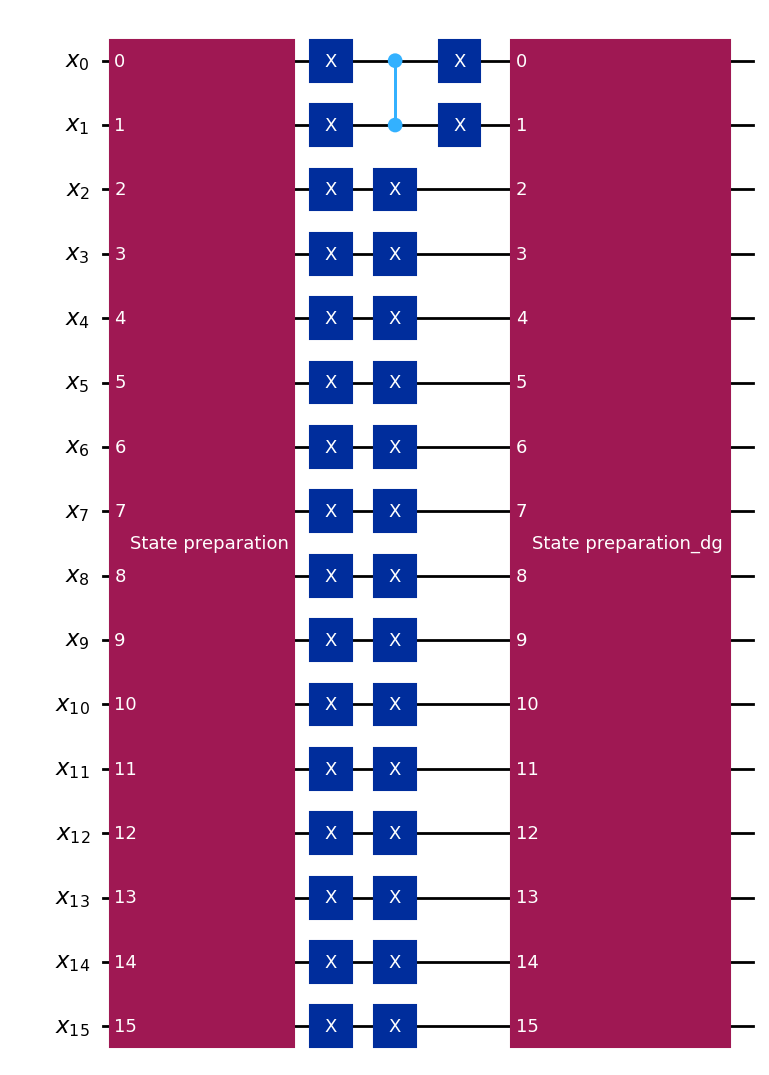

In [5]:

diffuser_circuit = QuantumCircuit(quantum_register, name="diffuser")

### write the rest of the code below

diffuser_circuit.compose(Prep, inplace=True)

diffuser_circuit.x(quantum_register)
diffuser_circuit.cz(quantum_register[0], quantum_register[1])
diffuser_circuit.x(quantum_register)

diffuser_circuit.compose(Prep.inverse(), inplace=True)

###

diffuser_circuit.draw(output="mpl")

In [ ]:
U = marker_circuit.to_gate()
D = diffuser_circuit.to_gate()

What is the number of iteration, $K$, that you will need?

In [ ]:
n = 2
N = 2**n

### K = ? (write it as a function of N)

K = int(np.rint(np.pi / (4 * np.arcsin(1 / np.sqrt(N))) - 1/2))
K

1

# Full Grover circuit

Construct the full Grover search circuit and check the probabilities as the end.

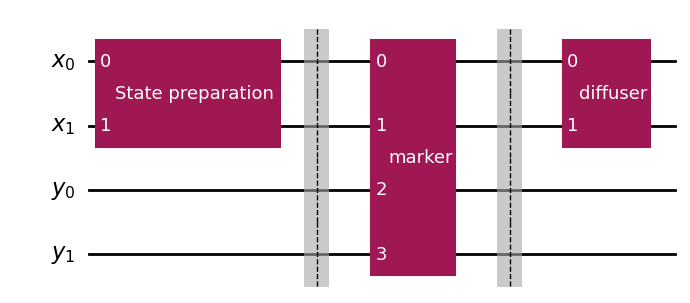

In [ ]:
quantum_register = QuantumRegister(size=2, name="x")
ancilla_register = AncillaRegister(size=2, name="y")

grover_circuit = QuantumCircuit(quantum_register, ancilla_register, name="Grover circuit")

### write the rest of the code below

grover_circuit.compose(Prep, qubits=quantum_register[:], inplace=True)

for _ in range(1):
    grover_circuit.barrier()
    grover_circuit.compose(U, inplace=True)
    grover_circuit.barrier()
    grover_circuit.compose(D, qubits=quantum_register[:], inplace=True)

###

grover_circuit.draw(output="mpl")

In [ ]:
psi = Statevector(grover_circuit)
psi.probabilities()

array([5.57706021e-34, 1.00000000e+00, 1.59557706e-68, 9.07105347e-35,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

Numerical noise makes it seem messy, so let's simplify:

In [ ]:
np.round(psi.probabilities(), 4)

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

Maximum probability at $\mathrm{index} = 1$, which is equivalent to $(x_0, x_1) = (1, 0)$, and $F (1, 0) = 2 \cdot 1 + 0 = 2$.

# Change in the probability density over the iterations

In [ ]:
n = 7
N = 2**n
K = int(np.rint(np.pi / (4 * np.arcsin(1 / np.sqrt(N))) - 1/2))
Theta = 2 * np.arcsin(1/np.sqrt(N))
K, Theta

(8, np.float64(0.1770076862880309))

In [ ]:
iterations = np.arange(1, 4 * K + 1) # let us allow under-, and overcooking
P_success_over_time = np.square(np.sin((iterations + 1/2) * Theta))

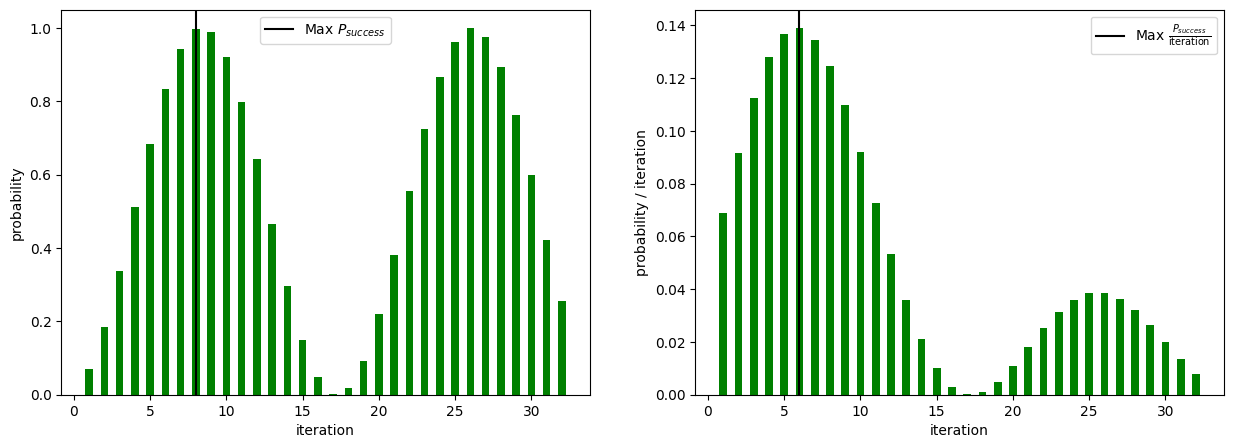

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=(15, 5))

axs[0].bar(iterations,
           P_success_over_time,
           width=0.5,
           color="green")
axs[0].set(xlabel=f"iteration",
           ylabel=f"probability")
axs[0].axvline(x = K,
               linewidth=1.5,
               color="black",
               label=r"Max $P_{success}$")

axs[0].legend(loc='best')

axs[1].bar(iterations,
           P_success_over_time / iterations,
           width=0.5,
           color="green")
axs[1].set(xlabel=f"iteration",
           ylabel=f"probability / iteration")
axs[1].axvline(x = iterations[np.argmax(P_success_over_time / iterations)],
               linewidth=1.5,
               color="black",
               label=r"Max $\frac{P_{success}}{\mathrm{iteration}}$")

axs[1].legend(loc='best')

plt.show()

NOTE: if you are optimizing for expected amounts of overall resources, then running $k = 6 (< 8 = K)$ iterations yields better results!